# 1. dataset preprocessing


##1.1 Dataset

###1.1.1 dataset downloading

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install -q kaggle
from google.colab import files
files.upload()
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
%cd /content/drive/MyDrive/DataSets/
!kaggle datasets download adityajn105/flickr8k

Saving kaggle.json to kaggle.json
/content/drive/MyDrive/DataSets
Dataset URL: https://www.kaggle.com/datasets/adityajn105/flickr8k
License(s): CC0-1.0
 98% 1.01G/1.04G [00:06<00:00, 155MB/s]
100% 1.04G/1.04G [00:06<00:00, 159MB/s]


In [3]:
path = '/content/drive/MyDrive/DataSets/'
import zipfile
with zipfile.ZipFile(path+'flickr8k.zip', 'r') as zip_ref:
    zip_ref.extractall(path)

###1.1.2 showing an example


picture name is: 1000268201_693b08cb0e
picture format is: .jpg


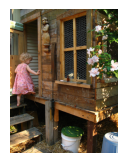

Captions:
1 _ A child in a pink dress is climbing up a set of stairs in an entry way .
2 _ A girl going into a wooden building .
3 _ A little girl climbing into a wooden playhouse .
4 _ A little girl climbing the stairs to her playhouse .
5 _ A little girl in a pink dress going into a wooden cabin .


picture name is: 1001773457_577c3a7d70
picture format is: .jpg


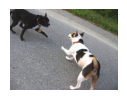

Captions:
1 _ A black dog and a spotted dog are fighting
2 _ A black dog and a tri-colored dog playing with each other on the road .
3 _ A black dog and a white dog with brown spots are staring at each other in the street .
4 _ Two dogs of different breeds looking at each other on the road .
5 _ Two dogs on pavement moving toward each other .


picture name is: 1002674143_1b742ab4b8
picture format is: .jpg


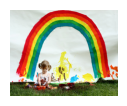

Captions:
1 _ A little girl covered in paint sits in front of a painted rainbow with her hands in a bowl .
2 _ A little girl is sitting in front of a large painted rainbow .
3 _ A small girl in the grass plays with fingerpaints in front of a white canvas with a rainbow on it .
4 _ There is a girl with pigtails sitting in front of a rainbow painting .
5 _ Young girl with pigtails painting outside in the grass .


picture name is: 1003163366_44323f5815
picture format is: .jpg


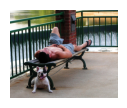

Captions:
1 _ A man lays on a bench while his dog sits by him .
2 _ A man lays on the bench to which a white dog is also tied .
3 _ a man sleeping on a bench outside with a white and black dog sitting next to him .
4 _ A shirtless man lies on a park bench with his dog .
5 _ man laying on bench holding leash of dog sitting on ground




In [ ]:
##importing lib
import os
import matplotlib.pyplot as plt
from PIL import Image

data_img_directory= '/content/drive/MyDrive/DataSets/Images'
data_cpt_directory= '/content/drive/MyDrive/DataSets/captions.txt'


##openting caption.txt
with open(data_cpt_directory, 'r') as f:
    all_captions=f.readlines()

picture=os.listdir(data_img_directory)

plot_picture=[f for f in picture if f.endswith('.jpg')][:4]
for i, pi in enumerate(plot_picture):
    img_path=os.path.join(data_img_directory,pi)
    name=os.path.splitext(pi)[0]
    format=os.path.splitext(pi)[1]
    print(f'picture name is: {name}')
    print(f'picture format is: {format}')
    img=Image.open(img_path)
    plt.subplot(1, 4, i + 1)
    plt.imshow(img)
    plt.axis('off')
    plt.show()

    #Find and print captions for this image
    q=1
    print("Captions:")
    for line in all_captions:

       if line.startswith(name):
          caption =line.split(f'{pi},')[1].strip()
          print(f'{q} _ {caption}')
          q+=1
    print('\n')

##1.2 Preprocessing

###1.2.1  picture preprocesing :Resize and Normalizing

In [5]:
from torchvision.transforms import transforms

pre_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

### 1.2.2 Catption preprocessing

In [ ]:
import re
import string

def clean_caption(caption):
    # Convert to lowercase
    caption=caption.lower()
    # Remove punctuation
    caption=caption.translate(str.maketrans('', '', string.punctuation))
    # Remove numbers
    caption=re.sub(r'\d+', '', caption)
    # Remove extra whitespace
    caption=caption.strip()
    caption=re.sub(r'\s+', ' ', caption) 

    return caption

original = "this is Hw4 first Question."
cleaned = clean_caption(original)
print(cleaned)

this is hw first question


In [7]:
import os
import re
import json
import torch
import spacy
import string
from PIL import Image
from tqdm import tqdm
from collections import Counter
from torch.utils.data import Dataset, DataLoader, random_split
from torch.nn.utils.rnn import pad_sequence
from torchvision import transforms

# Initialize spaCy English tokenizer
spacy_eng=spacy.load("en_core_web_sm")

# Special tokens
SOS_TOKEN= "<sos>"
EOS_TOKEN= "<eos>"
UNK_TOKEN= "<unk>"
PAD_TOKEN= "<pad>"



class Vocabulary:
    def __init__(self, freq_threshold=5):
        self.freq_threshold = freq_threshold
        self.itos={0: PAD_TOKEN, 1: SOS_TOKEN, 2: EOS_TOKEN, 3: UNK_TOKEN}
        self.stoi={PAD_TOKEN: 0, SOS_TOKEN: 1, EOS_TOKEN: 2, UNK_TOKEN: 3}

    def __len__(self):
        return len(self.itos)

    def tokenizer(self, text):
        return [tok.text.lower() for tok in spacy_eng.tokenizer(text)]

    def build_vocabulary(self, sentence_list):
        frequencies={}
        idx=4
        for sentence in sentence_list:
            for word in self.tokenizer(sentence):
                if word not in frequencies:
                    frequencies[word]=1
                else:
                    frequencies[word]+=1
                if frequencies[word]==self.freq_threshold:
                    self.stoi[word]=idx
                    self.itos[idx]=word
                    idx+=1

    def numericalize(self, text):
        tokens=self.tokenizer(text)
        return [self.stoi.get(tok, self.stoi[UNK_TOKEN]) for tok in tokens]

    def save_vocab(self, path='tokenizer.json'):
        with open(path, 'w') as f:
            json.dump({'stoi': self.stoi, 'itos': self.itos}, f)


In [8]:
class F8kDataset(Dataset):
    def __init__(self, image_dir, caption_path, transform=None, freq_threshold=5):
        self.image_dir=image_dir
        self.transform=transform

        with open(caption_path, 'r') as f:
            lines=f.readlines()

        self.samples=[]
        self.imgs={}

        all_captions=[]

        for line in tqdm(lines):
            line=line.strip()
            if len(line) < 10:
                continue

            if ',' in line:
                image_id, caption=line.split(',', 1)
            else:
                parts=line.split(None, 1)
                if len(parts) < 2:
                    continue
                image_id, caption=parts[0], parts[1]

            caption=clean_caption(caption)

            try:
                if image_id not in self.imgs:
                    self.imgs[image_id]=Image.open(os.path.join(image_dir, image_id)).convert("RGB")
                self.samples.append((image_id, caption))
                all_captions.append(caption)
            except:
                continue

        self.vocab=Vocabulary(freq_threshold)
        self.vocab.build_vocabulary(all_captions)
        self.vocab.save_vocab()
        self.vocab.save_vocab('/content/drive/MyDrive/DataSets/tokenizer.json')

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_id, caption=self.samples[idx]
        image=self.imgs[img_id]

        if self.transform is not None:
            image=self.transform(image)

        numerical_caption=[self.vocab.stoi[SOS_TOKEN]]
        numerical_caption+=self.vocab.numericalize(caption)
        numerical_caption.append(self.vocab.stoi[EOS_TOKEN])

        return image, torch.tensor(numerical_caption), img_id

In [9]:
class MyCollate:
    def __init__(self, pad_idx, max_length=20):
        self.pad_idx=pad_idx
        self.max_length=max_length

    def __call__(self, batch):
        imgs=[item[0].unsqueeze(0) for item in batch]
        imgs=torch.cat(imgs, dim=0)
        ids=[item[2] for item in batch]

        targets=[]
        for caption in [item[1] for item in batch]:
            length=caption.size(0)
            if length < self.max_length:
                padded=torch.cat([
                    caption,
                    torch.tensor([self.pad_idx] * (self.max_length - length))
                ])
            else:
                padded=caption[:self.max_length]
            targets.append(padded)

        targets=torch.stack(targets)
        return imgs, targets, ids

In [ ]:
from collections import defaultdict
from torch.utils.data import Dataset, DataLoader, Subset
import random

def get_loader(image_dir, caption_path, transform, batch_size=32, num_workers=2, shuffle=True, freq_threshold=5):
    full_dataset=F8kDataset(image_dir, caption_path, transform, freq_threshold)
    pad_idx=full_dataset.vocab.stoi[PAD_TOKEN]

    #samples Group  by image_id
    image_to_indices=defaultdict(list)
    for idx, (img_id, _) in enumerate(full_dataset.samples):
        image_to_indices[img_id].append(idx)

    image_ids=list(image_to_indices.keys())
    random.shuffle(image_ids)

    total_images=len(image_ids)
    train_end=int(0.8 * total_images)
    val_end=train_end + int(0.1 * total_images)

    train_ids=set(image_ids[:train_end])
    val_ids=set(image_ids[train_end:val_end])
    test_ids=set(image_ids[val_end:])

    def gather_indices(image_set):
        indices=[]
        for img_id in image_set:
            indices.extend(image_to_indices[img_id])
        return indices

    train_indices=gather_indices(train_ids)
    val_indices=gather_indices(val_ids)
    test_indices=gather_indices(test_ids)

    train_set=Subset(full_dataset, train_indices)
    val_set=Subset(full_dataset, val_indices)
    test_set=Subset(full_dataset, test_indices)

    train_loader=DataLoader(train_set, batch_size=batch_size, shuffle=shuffle,
                              collate_fn=MyCollate(pad_idx), num_workers=num_workers)
    val_loader=DataLoader(val_set, batch_size=batch_size, shuffle=False,
                            collate_fn=MyCollate(pad_idx), num_workers=num_workers)
    test_loader=DataLoader(test_set, batch_size=batch_size, shuffle=False,
                             collate_fn=MyCollate(pad_idx), num_workers=num_workers)

    return train_loader, val_loader, test_loader, full_dataset

In [11]:

data_img_directory= '/content/drive/MyDrive/DataSets/Images'
data_cpt_directory= '/content/drive/MyDrive/DataSets/captions.txt'


In [ ]:
import os, re, json, torch, spacy, string

train_loader, val_loader, test_loader, dataset = get_loader(
    image_dir=data_img_directory,caption_path=data_cpt_directory,transform=pre_transform,
    batch_size=32,num_workers=2,shuffle=True,freq_threshold=5 
)

100%|██████████| 40456/40456 [02:09<00:00, 312.56it/s]


# 2.model


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models

#CNN for ENcoder Resnet 50
class EncoderCNN(nn.Module):
    def __init__(self, embed_size):
        super(EncoderCNN, self).__init__()
        resnet=models.resnet50(pretrained=True)
        for param in resnet.parameters():
            param.requires_grad=False
        modules=list(resnet.children())[:-1]
        self.resnet=nn.Sequential(*modules)
        self.linear=nn.Linear(resnet.fc.in_features, embed_size)
        self.bn=nn.BatchNorm1d(embed_size, momentum=0.01)

    def forward(self, images):
        with torch.no_grad():
            features=self.resnet(images)
        features=features.view(features.size(0), -1)
        features=self.bn(self.linear(features))
        return features


# hybrid Lstm GRu from the paper
class HybridDecoder(nn.Module):
    def __init__(self, embed_size, hidden_size, vocab_size, num_layers=1, dropout=0.5):
        super(HybridDecoder, self).__init__()
        self.embed=nn.Embedding(vocab_size, embed_size)
        self.lstm=nn.LSTM(embed_size, hidden_size, num_layers, batch_first=True)
        self.gru=nn.GRU(hidden_size, hidden_size, num_layers, batch_first=True)
        self.dropout=nn.Dropout(dropout)
        self.fc=nn.Linear(hidden_size, vocab_size)

        self.init_h=nn.Linear(embed_size, hidden_size)
        self.init_c=nn.Linear(embed_size, hidden_size)

    def forward(self, features, captions):
        embeddings=self.embed(captions)
        h0=self.init_h(features).unsqueeze(0)  
        c0=self.init_c(features).unsqueeze(0)
        lstm_out, _ =self.lstm(embeddings, (h0, c0))
        gru_out, _=self.gru(lstm_out)
        outputs=self.fc(self.dropout(gru_out))
        return outputs

    def greedy_search(self, features, vocab, max_len=20):
        output=[]
        h0=self.init_h(features).unsqueeze(0)
        c0=self.init_c(features).unsqueeze(0)
        lstm_state=(h0, c0)
        gru_state=h0
        input=self.embed(torch.tensor([vocab.stoi[SOS_TOKEN]], device=features.device)).unsqueeze(0)

        for _ in range(max_len):
            lstm_out, lstm_state=self.lstm(input, lstm_state)
            gru_out, gru_state=self.gru(lstm_out, gru_state)
            logits=self.fc(self.dropout(gru_out.squeeze(1)))
            predicted=logits.argmax(1)
            output.append(predicted.item())

            if predicted.item()==vocab.stoi[EOS_TOKEN]:
                break

            input=self.embed(predicted).unsqueeze(1)

        return [vocab.itos[idx] for idx in output if idx not in [vocab.stoi[SOS_TOKEN], vocab.stoi[PAD_TOKEN]]]

    def beam_search(self, features, vocab, beam_width=3, max_len=20):
        init_h=self.init_h(features).unsqueeze(0)
        init_c=self.init_c(features).unsqueeze(0)
        sos_token=torch.tensor([vocab.stoi[SOS_TOKEN]], device=features.device)
        start_input=self.embed(sos_token).unsqueeze(0)
        sequences=[[[], 0.0, (init_h, init_c), init_h, start_input]]

        for _ in range(max_len):
            all_candidates=[]
            for seq, score, lstm_state, gru_state, inp in sequences:
                lstm_out, lstm_state_new=self.lstm(inp, lstm_state)
                gru_out, gru_state_new=self.gru(lstm_out, gru_state)
                output=self.fc(self.dropout(gru_out[:, -1, :]))
                probs=F.log_softmax(output, dim=1)
                topk_probs, topk_idx=probs.topk(beam_width, dim=1)

                for i in range(beam_width):
                    word_idx=topk_idx[0][i].item()
                    word_score=topk_probs[0][i].item()
                    next_seq=seq + [word_idx]
                    next_input=self.embed(torch.tensor([word_idx], device=features.device)).unsqueeze(1)
                    all_candidates.append((next_seq, score + word_score, lstm_state_new, gru_state_new, next_input))

            sequences=sorted(all_candidates, key=lambda x: x[1], reverse=True)[:beam_width]

        best_seq=sequences[0][0]
        return [vocab.itos[idx] for idx in best_seq if idx not in [vocab.stoi[SOS_TOKEN], vocab.stoi[PAD_TOKEN]]]


class HybridModel(nn.Module):
    def __init__(self, embed_size, hidden_size, vocab_size):
        super(HybridModel, self).__init__()
        self.encoder=EncoderCNN(embed_size)
        self.decoder=HybridDecoder(embed_size, hidden_size, vocab_size)

    def forward(self, images, captions):
        features=self.encoder(images)
        return self.decoder(features, captions)

    def generate_caption(self, image, vocab, method="greedy", beam_width=5, max_len=20):
        features=self.encoder(image.unsqueeze(0))
        if method=="greedy":
            return self.decoder.greedy_search(features, vocab, max_len)
        elif method=="beam":
            return self.decoder.beam_search(features, vocab, beam_width, max_len)


In [ ]:
import torch.optim as optim
import torch.nn as nn

device=torch.device("cuda" if torch.cuda.is_available() else "cpu")

vocab_size=len(dataset.vocab)
embed_size=256
hidden_size=512


pad_idx=train_loader.collate_fn.pad_idx
pad_idx=dataset.vocab.stoi[PAD_TOKEN]
criterion=nn.CrossEntropyLoss(ignore_index=pad_idx)
model=HybridModel(embed_size, hidden_size, vocab_size).to(device)
optimizer=optim.Adam(model.parameters(), lr=1e-3)


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 165MB/s]


In [ ]:
import torch
import os
import json
import matplotlib.pyplot as plt

import time
def train(model, train_loader, val_loader, criterion, optimizer, num_epochs, vocab, save_dir='checkpoints'):
    device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model=model.to(device)

    train_losses=[]
    val_losses=[]
    best_val_loss=float("inf")
    start_epoch=0

    if not os.path.exists(save_dir):
        os.makedirs(save_dir)

    loss_path=os.path.join(save_dir, 'loss_history.json')
    checkpoint_path=os.path.join(save_dir, 'best_model.pth')


    if os.path.exists(loss_path):
        with open(loss_path, 'r') as f:
            history=json.load(f)
            train_losses=history.get('train', [])
            val_losses=history.get('val', [])

    if os.path.exists(checkpoint_path):
        print("Resuming from saved checkpoint...")
        checkpoint=torch.load(checkpoint_path)
        model.load_state_dict(checkpoint['model_state_dict'])
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        best_val_loss=checkpoint['val_loss']
        start_epoch=checkpoint['epoch'] + 1

    try:
        for epoch in range(num_epochs):
            model.train()
            total_train_loss=0

            start_time=time.time()

            for images, captions, _ in train_loader:
                images, captions=images.to(device), captions.to(device)
                outputs=model(images, captions)

                loss=criterion(outputs[:, :-1, :].reshape(-1, vocab_size), captions[:, 1:].reshape(-1))
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

                total_train_loss+=loss.item()

            avg_train_loss=total_train_loss / len(train_loader)
            train_losses.append(avg_train_loss)

        # Validation
            model.eval()
            total_val_loss=0
            with torch.no_grad():
                for images, captions, _ in val_loader:
                    images, captions=images.to(device), captions.to(device)
                    outputs=model(images, captions)
                    loss=criterion(outputs[:, :-1, :].reshape(-1, vocab_size), captions[:, 1:].reshape(-1))
                    total_val_loss+=loss.item()

            avg_val_loss=total_val_loss / len(val_loader)
            val_losses.append(avg_val_loss)

            end_time=time.time()

            print(f" Epoch number {epoch+1} takes {(end_time - start_time) / 60:.2f} minutes,: Train Loss: {avg_train_loss:.4f} & Val Loss: {avg_val_loss:.4f}")

        #Saving model checkpoint
            if avg_val_loss < best_val_loss:
                best_val_loss = avg_val_loss
                torch.save({
                    'epoch': epoch,
                    'model_state_dict': model.state_dict(),
                    'optimizer_state_dict': optimizer.state_dict(),
                    'val_loss': best_val_loss
                }, checkpoint_path)
                print("Checkpoint, BEST MODEL TILL NOW")
            ##saving our losses
            with open(loss_path, 'w') as f:
                json.dump({'train': train_losses, 'val': val_losses}, f)

    except KeyboardInterrupt:
        print("Training interrupted. Model and losses saved.")

    # Plotting
    plt.plot(train_losses, label="Training Loss")
    plt.plot(val_losses, label="Validation Loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss Value")
    plt.title("Training and Validation Loss per epoch")
    plt.legend()
    plt.show()

    return model


 Epoch number 1 takes 2.57 minutes,: Train Loss: 3.6148 & Val Loss: 3.1384
Checkpoint, BEST MODEL TILL NOW
 Epoch number 2 takes 2.56 minutes,: Train Loss: 2.9322 & Val Loss: 2.9418
Checkpoint, BEST MODEL TILL NOW
 Epoch number 3 takes 2.51 minutes,: Train Loss: 2.6881 & Val Loss: 2.8873
Checkpoint, BEST MODEL TILL NOW
 Epoch number 4 takes 2.51 minutes,: Train Loss: 2.5104 & Val Loss: 2.8675
Checkpoint, BEST MODEL TILL NOW
 Epoch number 5 takes 2.49 minutes,: Train Loss: 2.3620 & Val Loss: 2.8808
 Epoch number 6 takes 2.50 minutes,: Train Loss: 2.2243 & Val Loss: 2.9243
 Epoch number 7 takes 2.51 minutes,: Train Loss: 2.0999 & Val Loss: 2.9583
 Epoch number 8 takes 2.48 minutes,: Train Loss: 1.9814 & Val Loss: 3.0330
 Epoch number 9 takes 2.50 minutes,: Train Loss: 1.8773 & Val Loss: 3.0749
 Epoch number 10 takes 2.53 minutes,: Train Loss: 1.7818 & Val Loss: 3.1599
 Epoch number 11 takes 2.62 minutes,: Train Loss: 1.6969 & Val Loss: 3.2050
 Epoch number 12 takes 2.62 minutes,: Train L

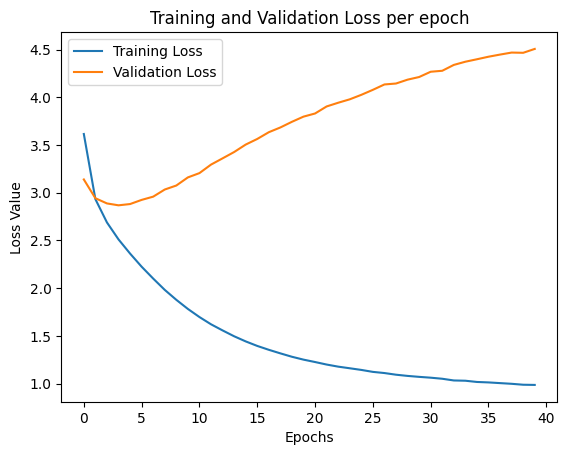

In [16]:
num_epochs=40
import time
model=train(model, train_loader, val_loader, criterion, optimizer, num_epochs, dataset.vocab, save_dir='/content/drive/MyDrive/checkpoints')

#Model analyzing

In [ ]:
import matplotlib.pyplot as plt
import torchvision.transforms as T

def denormalize(image_tensor):
    mean=torch.tensor([0.485, 0.456, 0.406]).to(image_tensor.device)
    std=torch.tensor([0.229, 0.224, 0.225]).to(image_tensor.device)
    return image_tensor * std[:, None, None] + mean[:, None, None]

def clean_caption2(tokens, eos_token='<eos>'):
    try:
        return tokens[:tokens.index(eos_token)]
    except ValueError:
        return tokens


def show_caption_examples(model, test_loader, vocab, num_examples=5, beam_width=5):
    model.eval()
    device=next(model.parameters()).device
    shown=0
    shown_ids=set()

    for images, _, img_ids in test_loader:
        for i in range(images.size(0)):
            img_tensor=images[i].to(device)
            img_id=img_ids[i]

            if img_id in shown_ids:
                continue

            shown_ids.add(img_id)

            #Generating captions
            greedy_caption = clean_caption2(model.generate_caption(img_tensor, vocab, method="greedy"))
            beam_caption = clean_caption2(model.generate_caption(img_tensor, vocab, method="beam", beam_width=beam_width))

            #Denormalize and display
            img_vis=denormalize(img_tensor).cpu().clamp(0, 1).permute(1, 2, 0).numpy()
            plt.imshow(img_vis)
            plt.axis('off')
            plt.title(f"Greedy: {' '.join(greedy_caption)}\nBeam:   {' '.join(beam_caption)}")
            plt.show()

            shown += 1
            if shown >= num_examples:
                return


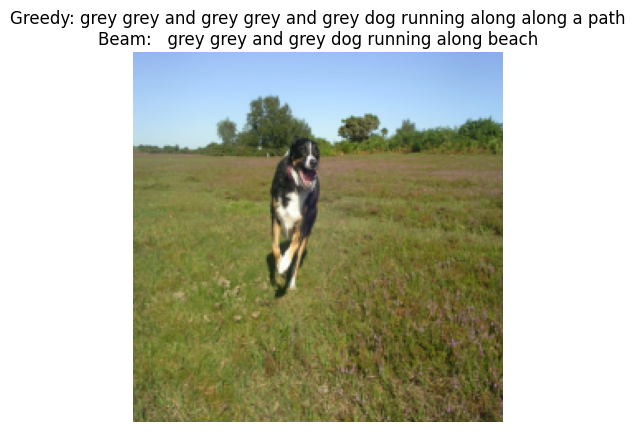

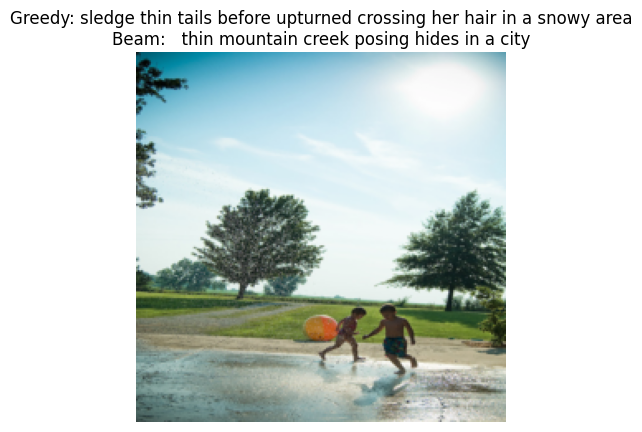

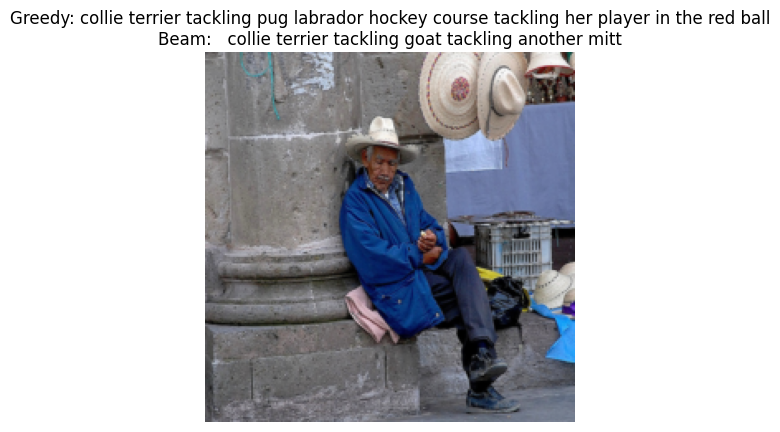

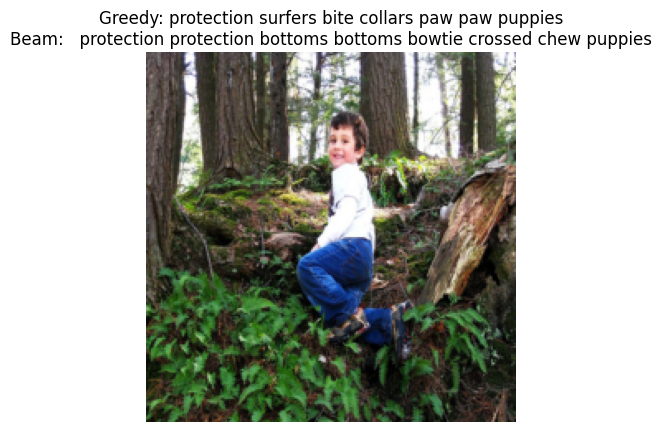

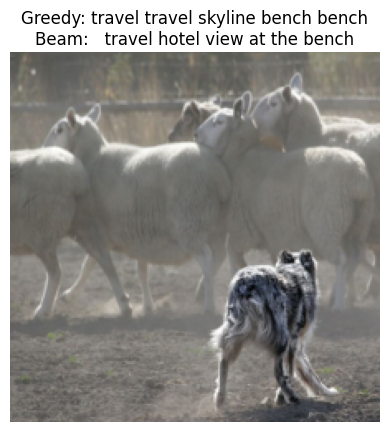

In [33]:
show_caption_examples(model, test_loader, dataset.vocab, num_examples=5)

## emtiaziii

In [21]:
import json
from collections import defaultdict
import spacy
# Load tokenizer
with open('/content/drive/MyDrive/DataSets/tokenizer.json', 'r') as f:
    tokenizer_data = json.load(f)

stoi=tokenizer_data["stoi"]
itos={int(i): w for i, w in tokenizer_data["itos"].items()} if "itos" in tokenizer_data else {v: k for k, v in stoi.items()}

spacy_eng=spacy.load("en_core_web_sm")
def tokenizer(text):
    return [tok.text.lower() for tok in spacy_eng.tokenizer(text)]

reference_dictionary=defaultdict(list)

for img_id, caption in dataset.samples:
    tokens=tokenizer(caption)
    reference_dictionary[img_id].append(tokens)

In [ ]:
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction

def compute_bleu_scores(model, test_loader, vocab, reference_dictionary, method="greedy", beam_width=5, max_len=20):

    model.eval()
    device = next(model.parameters()).device
    smoothie = SmoothingFunction().method4

    hypotheses = []
    references = []

    for images, _, img_ids in test_loader:
        for img, img_id in zip(images, img_ids):
            img=img.to(device)
            img_id=str(img_id)

            #Generate caption
            pred=model.generate_caption(img, vocab,method=method,beam_width=beam_width,)

            #Add to lists
            hypotheses.append(pred)
            references.append(reference_dictionary[img_id]) 

    scores = {
        "BLEU-1": corpus_bleu(references, hypotheses, weights=(1, 0, 0, 0), smoothing_function=smoothie),
        "BLEU-2": corpus_bleu(references, hypotheses, weights=(0.5, 0.5, 0, 0), smoothing_function=smoothie),
        "BLEU-3": corpus_bleu(references, hypotheses, weights=(1/3, 1/3, 1/3, 0), smoothing_function=smoothie),
        "BLEU-4": corpus_bleu(references, hypotheses, weights=(0.25, 0.25, 0.25, 0.25), smoothing_function=smoothie),
    }

    return scores


In [23]:
# Compute BLEU scores
bleu_greedy=compute_bleu_scores(model=model, test_loader=test_loader,vocab=dataset.vocab,reference_dictionary=reference_dictionary,)

bleu_beam=compute_bleu_scores(model=model,test_loader=test_loader,vocab=dataset.vocab,reference_dictionary=reference_dictionary,method="beam",beam_width=5)

# Display as table
print("BLEU Score Table")
print(f"{'Method':<10} | {'Greedy':<8} | {'Beam':<8}")
print("-" * 35)
for metric in ["BLEU-1", "BLEU-2", "BLEU-3", "BLEU-4"]:
    print(f"{metric:<10} | {bleu_greedy[metric]:<8.4f} | {bleu_beam[metric]:<8.4f}")


BLEU Score Table
Method     | Greedy   | Beam    
-----------------------------------
BLEU-1     | 0.1923   | 0.0859  
BLEU-2     | 0.0843   | 0.0356  
BLEU-3     | 0.0372   | 0.0141  
BLEU-4     | 0.0150   | 0.0059  


In [ ]:
import pandas as pd
df_bleu = pd.DataFrame({
    "Method": ["BLEU-1", "BLEU-2", "BLEU-3", "BLEU-4"],
    "Greedy": [bleu_greedy["BLEU-1"], bleu_greedy["BLEU-2"],bleu_greedy["BLEU-3"], bleu_greedy["BLEU-4"]],          
    "Beam": [bleu_beam["BLEU-1"], bleu_beam["BLEU-2"],bleu_beam["BLEU-3"], bleu_beam["BLEU-4"]]
             
})

df_bleu.to_excel("/content/drive/MyDrive/bleu_score_results.xlsx", index=False)